In [10]:
import pandas as pd
train = pd.read_csv('./train.csv', sep=',')

In [11]:
train.head()

,Compound,SMILES,Lab,RT,mol,ECFP_1,ECFP_2,ECFP_3,ECFP_4,ECFP_5,...,ECFP_1015,ECFP_1016,ECFP_1017,ECFP_1018,ECFP_1019,ECFP_1020,ECFP_1021,ECFP_1022,ECFP_1023,ECFP_1024
0,Hydroxytriazolam,OCc1nnc2n1-c1ccc(Cl)cc1C(c1ccccc1Cl)=NC2,CFSRE,7.02,<rdkit.Chem.rdchem.Mol object at 0x2aab375ee880>,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,5-MeO-DIPT,COc1ccc2[nH]cc(CCN(C(C)C)C(C)C)c2c1,Aarhus,4.45,<rdkit.Chem.rdchem.Mol object at 0x2aab37643680>,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,MDMA,CNC(C)Cc1ccc2c(c1)OCO2,Ghent University,3.14,<rdkit.Chem.rdchem.Mol object at 0x2aab378ea730>,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Despropionyl N-Benzyl para-Fluoro Norfentanyl,Fc1ccc(NC2CCN(Cc3ccccc3)CC2)cc1,San Francisco OCME,5.95,<rdkit.Chem.rdchem.Mol object at 0x2aab3790f3e0>,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,N-Ethylpentylone,CCCC(NCC)C(=O)c1ccc2c(c1)OCO2,Ghent University,4.21,<rdkit.Chem.rdchem.Mol object at 0x2aab378eadc0>,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


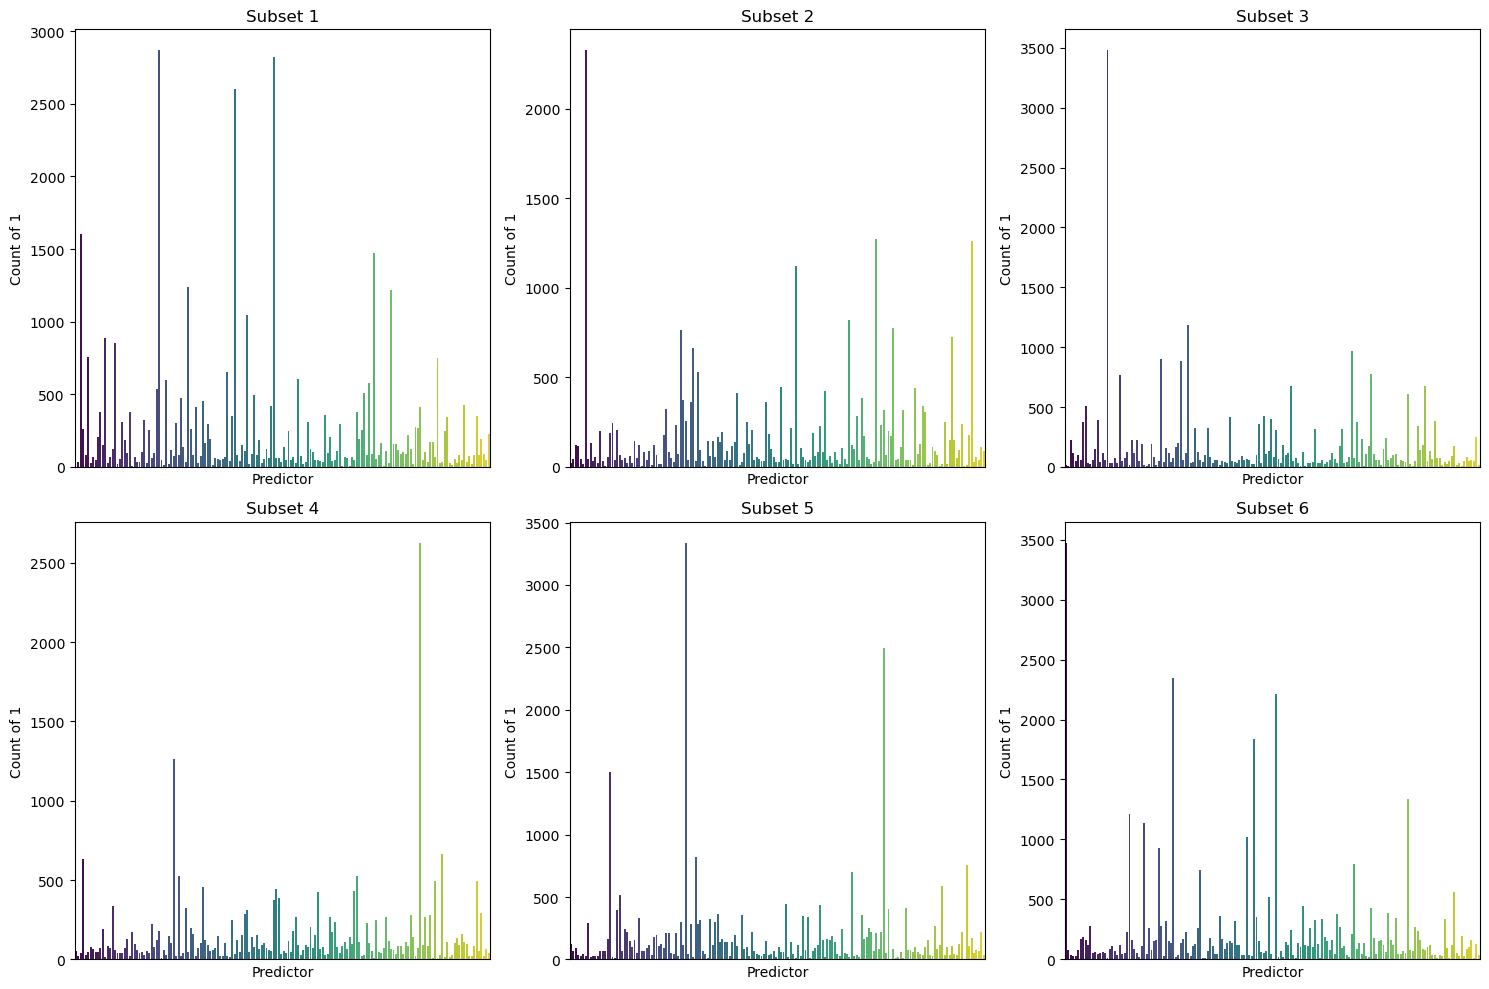

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('train.csv').drop(['Compound', 'SMILES', 'mol', 'Lab'], axis=1)
# Choose a subset of predictors for visualization (e.g., first 5 predictors)

# Number of rows and columns for the subplot grid
num_rows = 2
num_cols = 3
num_subsets = num_rows * num_cols

# Calculate the number of predictors in each subset
predictors_per_subset = len(df.columns) // num_subsets

# Create subplots
fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(15, 10))

# Flatten the 2D array of subplots to simplify indexing
axes = axes.flatten()

# Loop through subsets
for i, ax in enumerate(axes):
    # Calculate the starting and ending index for the subset
    start_idx = i * predictors_per_subset
    end_idx = (i + 1) * predictors_per_subset

    # Subset the predictors
    subset_predictors = df.iloc[:, start_idx:end_idx]

    # Add the target variable to the subset
    subset_predictors['target_variable'] = df['RT']

    # Reshape the data for Seaborn bar plots
    data_to_plot_melted = subset_predictors.melt(id_vars='target_variable', var_name='Predictor', value_name='Binary Value')

    # Filter rows where Binary Value is 1
    data_to_plot_melted = data_to_plot_melted[data_to_plot_melted['Binary Value'] == 1]

    # Create bar plots
    sns.countplot(data=data_to_plot_melted, x='Predictor', palette='viridis', ax=ax)
    ax.set_title(f'Subset {i + 1}')
    ax.set_xlabel('Predictor')
    ax.set_ylabel('Count of 1')
    ax.set_xticks([])  # Hide x-axis ticks

# Adjust layout
plt.tight_layout()
plt.show()


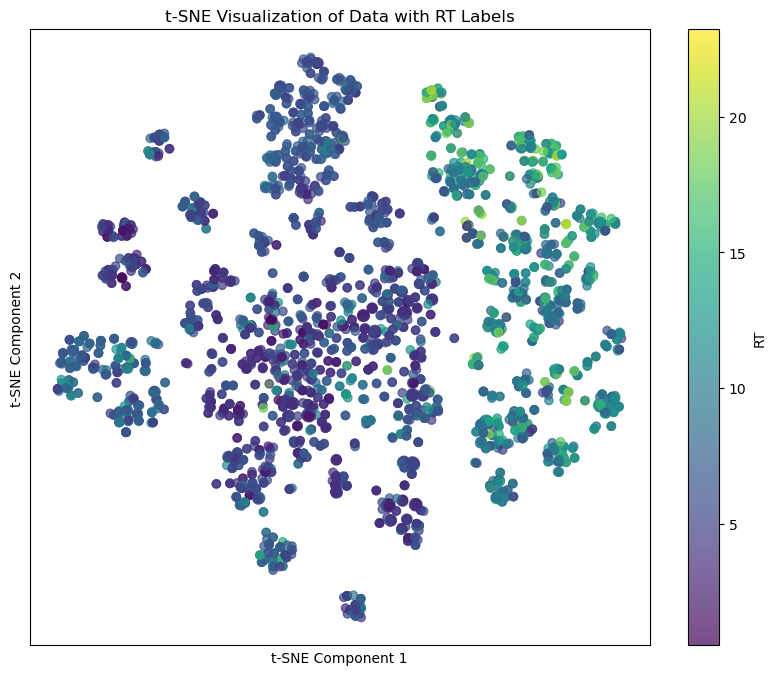

In [2]:
import pandas as pd
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('train.csv').drop(['Compound', 'SMILES', 'mol', 'Lab'], axis=1)

# Extract the target variable
y = df['RT']

# Drop the target variable from the DataFrame
X = df.drop('RT', axis=1)

# Perform t-SNE dimensionality reduction
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X)

# Create a new DataFrame for the t-SNE results
tsne_df = pd.DataFrame(data=X_tsne, columns=['tsne1', 'tsne2'])
tsne_df['RT'] = y  # Add the target variable back to the DataFrame

# Scatter plot
plt.figure(figsize=(10, 8))
plt.scatter(tsne_df['tsne1'], tsne_df['tsne2'], c=tsne_df['RT'], cmap='viridis', alpha=0.7)
plt.title('t-SNE Visualization of Data with RT Labels')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.colorbar(label='RT')
plt.xticks([], [])  # Hide x-axis ticks
plt.yticks([], [])  # Hide y-axis ticks

plt.show()



-SNE Component 1 and Component 2: 
These are the two new features (dimensions) created by t-SNE. 
Each data point in your original dataset is now represented by a pair of values in this 2D space (Component 1, Component 2). 
Similar samples in the original high-dimensional space are also close to each other in the t-SNE space.

The interpretation of the components can be challenging because t-SNE doesn't preserve global structures. 
Instead, it focuses on preserving local neighborhoods. Distances between points in the t-SNE plot don't have a meaningful interpretation 
in terms of the original feature values. 

The main use of t-SNE is in visualization and exploration of high-dimensional datasets. 
It helps you identify clusters, patterns, or outliers in your data by looking at the 2D representation. 
Keep in mind that t-SNE is sensitive to hyperparameters, and different runs might yield slightly different results. 
It's often used as an exploratory tool to gain insights into the structure of your data rather than as a definitive analysis tool.

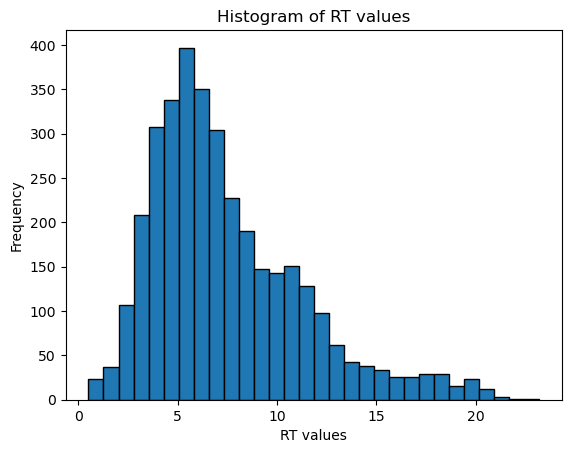

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('train.csv')
rt_values = df['RT']

# Plotting the histogram
plt.hist(rt_values, bins=30, edgecolor='black')
plt.title('Histogram of RT values')
plt.xlabel('RT values')
plt.ylabel('Frequency')
plt.show()

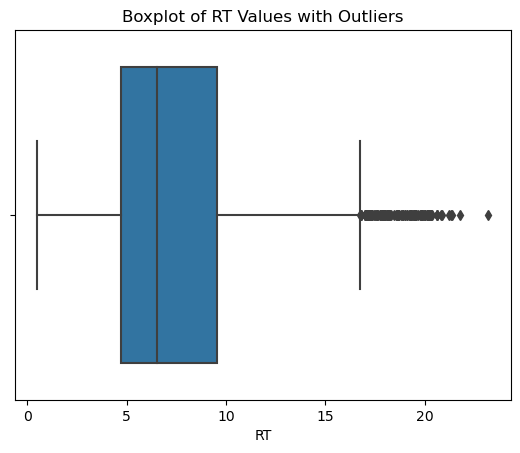

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your data is in a DataFrame called 'df'

sns.boxplot(x=df['RT'], showfliers=True)
plt.title('Boxplot of RT Values with Outliers')
plt.show()

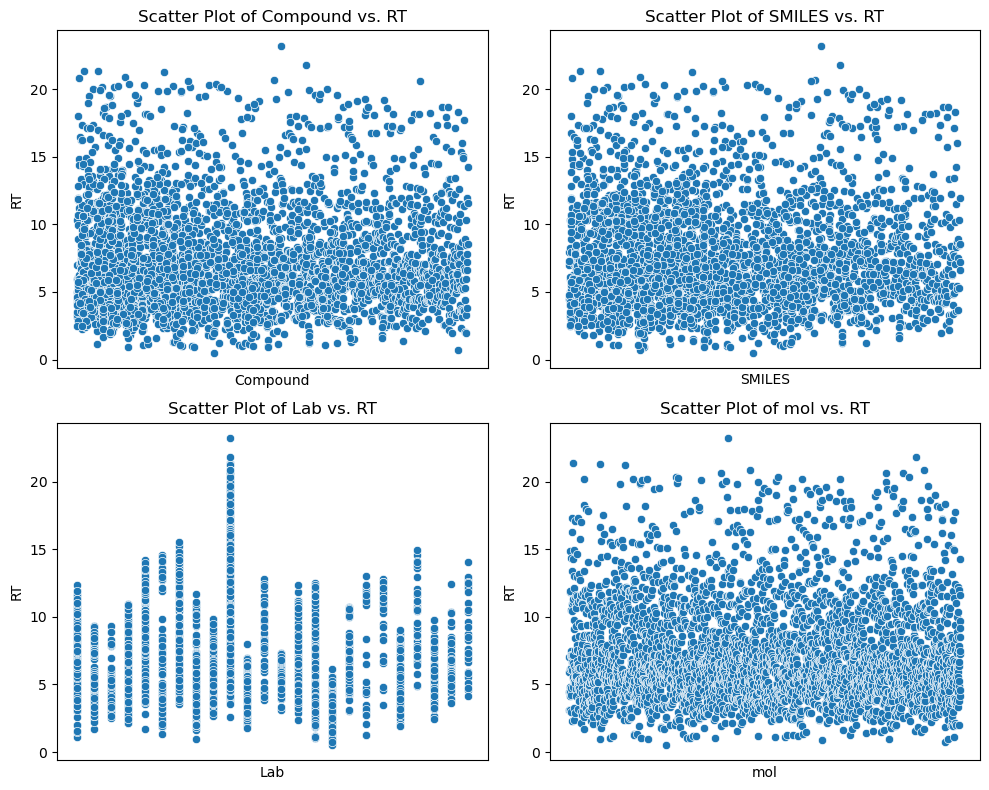

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a 2x2 grid of subplots
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))

# Flatten the 2D array of subplots for easier indexing
axes = axes.flatten()

# List of predictor columns
predictors = ['Compound', 'SMILES', 'Lab', 'mol']

# Loop through each subplot and create a scatter plot
for i, predictor in enumerate(predictors):
    sns.scatterplot(x=predictor, y='RT', data=df, ax=axes[i])
    axes[i].set_title(f'Scatter Plot of {predictor} vs. RT')
    axes[i].set_xlabel(predictor)
    axes[i].set_ylabel('RT')

    # Hide x-axis ticks
    axes[i].set_xticks([])

# Adjust layout for better spacing
plt.tight_layout()

plt.show()


/Users/melina/opt/anaconda3/lib/python3.8/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


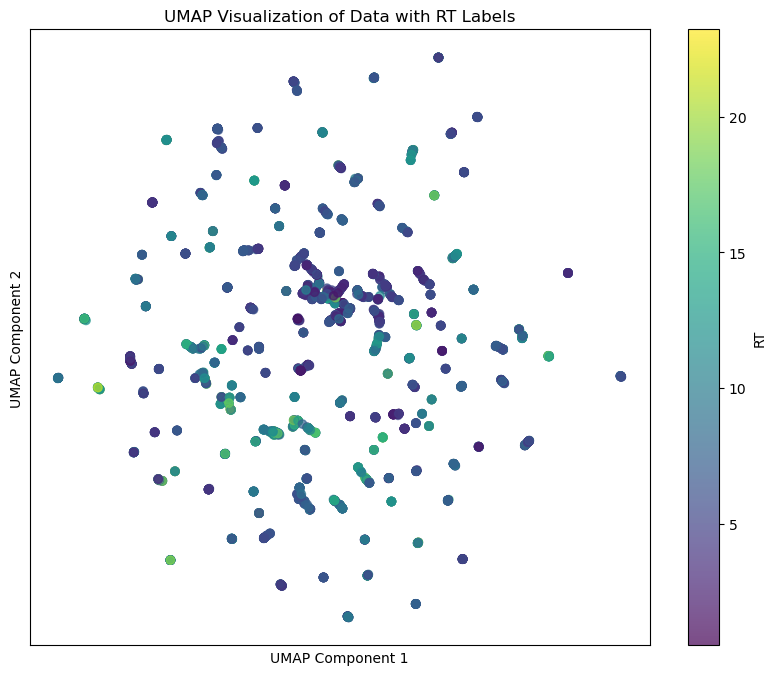

In [6]:
import pandas as pd
import umap.umap_ as umap  # Correct import statement
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('train.csv').drop(['Compound', 'SMILES', 'mol', 'Lab'], axis=1)

# Extract the target variable
y = df['RT']

# Drop the target variable from the DataFrame
X = df.drop('RT', axis=1)

# Perform UMAP dimensionality reduction
umap_model = umap.UMAP(n_components=2, random_state=42)
X_umap = umap_model.fit_transform(X)

# Create a new DataFrame for the UMAP results
umap_df = pd.DataFrame(data=X_umap, columns=['umap1', 'umap2'])
umap_df['RT'] = y  # Add the target variable back to the DataFrame

# Scatter plot
plt.figure(figsize=(10, 8))
plt.scatter(umap_df['umap1'], umap_df['umap2'], c=umap_df['RT'], cmap='viridis', alpha=0.7)
plt.title('UMAP Visualization of Data with RT Labels')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.colorbar(label='RT')
plt.xticks([], [])  # Hide x-axis ticks
plt.yticks([], [])  # Hide y-axis ticks

plt.show()


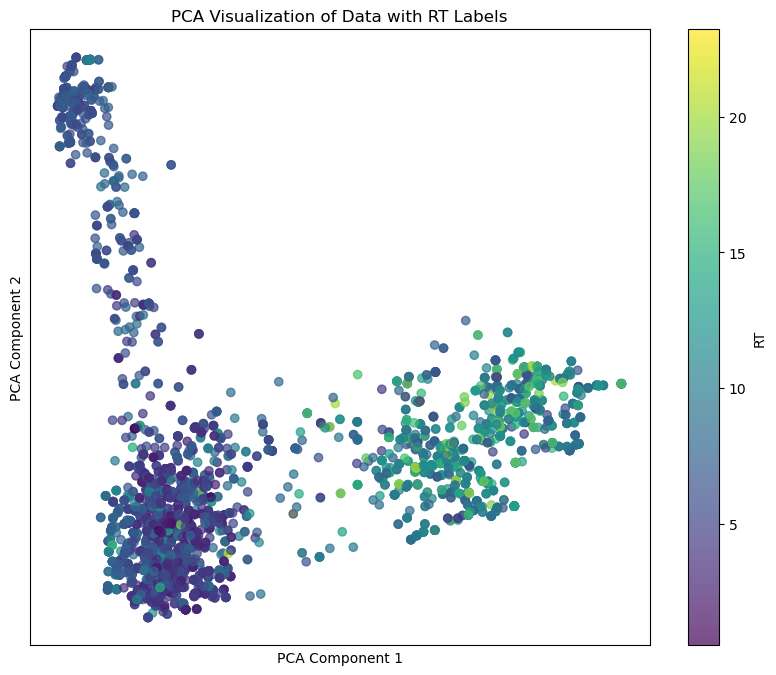

In [7]:
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('train.csv').drop(['Compound', 'SMILES', 'mol', 'Lab'], axis=1)

# Extract the target variable
y = df['RT']

# Drop the target variable from the DataFrame
X = df.drop('RT', axis=1)

# Perform PCA dimensionality reduction
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

# Create a new DataFrame for the PCA results
pca_df = pd.DataFrame(data=X_pca, columns=['pca1', 'pca2'])
pca_df['RT'] = y  # Add the target variable back to the DataFrame

# Scatter plot
plt.figure(figsize=(10, 8))
plt.scatter(pca_df['pca1'], pca_df['pca2'], c=pca_df['RT'], cmap='viridis', alpha=0.7)
plt.title('PCA Visualization of Data with RT Labels')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='RT')
plt.xticks([], [])  # Hide x-axis ticks
plt.yticks([], [])  # Hide y-axis ticks

plt.show()


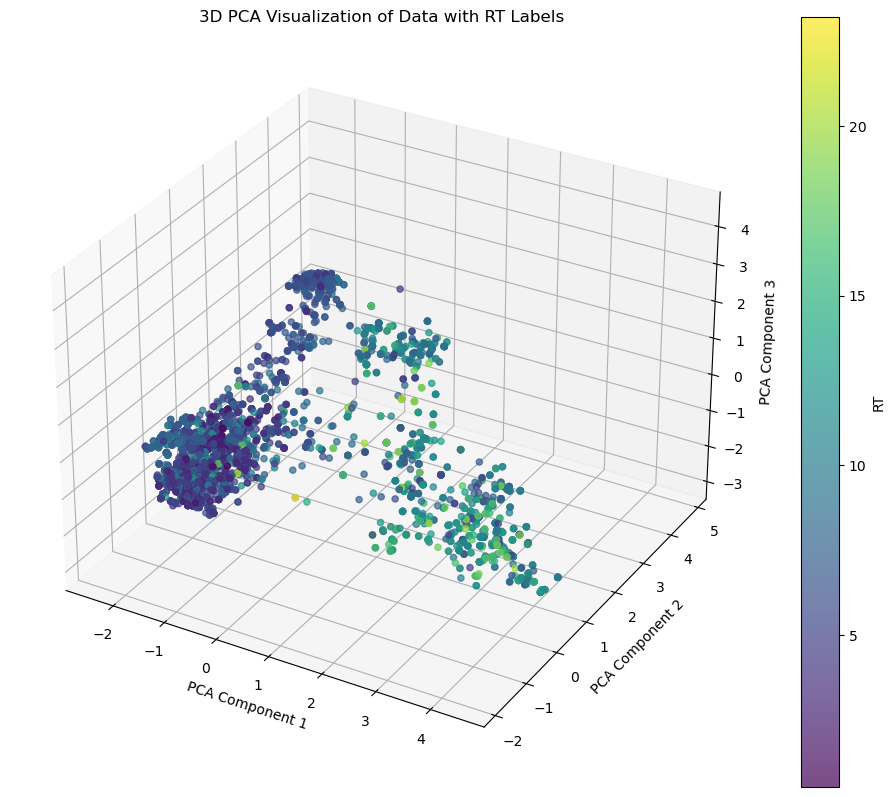

In [8]:
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Load the dataset
df = pd.read_csv('train.csv').drop(['Compound', 'SMILES', 'mol', 'Lab'], axis=1)

# Extract the target variable
y = df['RT']

# Drop the target variable from the DataFrame
X = df.drop('RT', axis=1)

# Perform PCA dimensionality reduction
pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X)

# Create a new DataFrame for the PCA results
pca_df = pd.DataFrame(data=X_pca, columns=['pca1', 'pca2', 'pca3'])
pca_df['RT'] = y  # Add the target variable back to the DataFrame

# 3D Scatter plot with grid
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot
sc = ax.scatter(pca_df['pca1'], pca_df['pca2'], pca_df['pca3'], c=pca_df['RT'], cmap='viridis', alpha=0.7)

# Add a grid
ax.grid(True)

# Set labels
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_zlabel('PCA Component 3')
ax.set_title('3D PCA Visualization of Data with RT Labels')

# Add a colorbar
cb = fig.colorbar(sc, ax=ax, label='RT')

plt.show()
